# Building a CNN Image Classifier - Rachel Wantuch
## Load the MNIST data set

In [50]:
from keras.datasets import mnist
from matplotlib import pyplot as plt

In [51]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

## Display the first 5 images

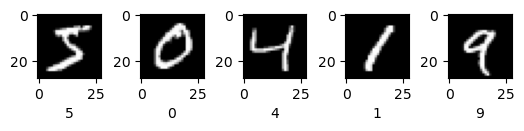

In [52]:
for i in range(5):
    plt.subplot(5,5,+1+i)
    plt.imshow(x_train[i],cmap=plt.get_cmap('gray'))
    plt.xlabel(str(y_train[i]))

plt.show()

## Build and train a CNN classifier on the MNIST training set
### Doing this using TensorFlow

In [53]:
import numpy as np

In [54]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten
from keras.layers import Conv2D, MaxPooling2D
#instead of np_utils the newer way is to use to_cateogrical
from keras.utils import to_categorical
from keras import backend as K

In [55]:
K.set_image_data_format("channels_first")

In [56]:
np.random.seed(42)

In [57]:
channels=1
height=28
width=28

In [58]:
data_train=x_train.reshape(x_train.shape[0],channels,height,width)

In [59]:
data_test=x_test.reshape(x_test.shape[0],channels,height,width)

In [60]:
#Rescale pixel intensity to between 0 and 1. Usuually the default max is 255
features_train=data_train/255
features_test=data_test/255

In [61]:
#one-hot encode the target
target_train=to_categorical(y_train)
target_test=to_categorical(y_test)
number_of_classes=target_test.shape[1]

In [62]:
#starting neural network
network=Sequential()

In [63]:
#Adding convolutional layer with 64 filters, a 5x5 window and ReLU activation function
network.add(Conv2D(filters=64,
                   kernel_size=(5,5),
                   input_shape=(channels,width,height),
                   activation='relu'))

In [64]:
#Add max pooling layer with a 2x2 window
network.add(MaxPooling2D(pool_size=(2,2)))

In [65]:
#add dropout layer
network.add(Dropout(0.5))

In [66]:
#Add layer to flatten input
network.add(Flatten())

In [67]:
#Add a fully connected layer of 128 units with a ReLU activation function
network.add(Dense(128,activation="relu"))

In [68]:
#Add another dropout layer
network.add(Dropout(0.5))

In [69]:
#Add fully connected layer with a softmax activation funtion
network.add(Dense(number_of_classes, activation="softmax"))

In [70]:
#compile neaural network
network.compile(loss="categorical_crossentropy",
                optimizer="rmsprop",
                metrics=["accuracy"])

In [71]:
#Train neural network
network.fit(features_train,target_train,epochs=2,verbose=0,batch_size=1000,
            validation_data=(features_test,target_test))

## Accuracy

In [72]:
test_loss,test_accuracy=network.evaluate(features_test,target_test)
print(f'Test accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9700 - loss: 0.0988
Test accuracy: 0.9700000286102295


## Confusion Matrix

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
[7 2 1 0 4 1 4 9 5 9 0]


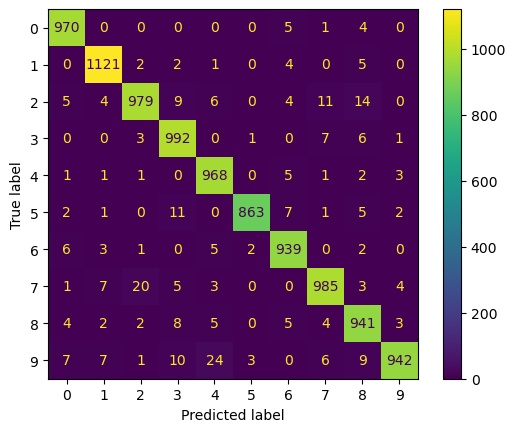

In [76]:
y_pred=network.predict(features_test)
y_pred=tf.math.argmax(y_pred,axis=1)
y_pred=y_pred.numpy()
print(y_pred[0:11])

cm=confusion_matrix(y_test,y_pred)
cm_display=ConfusionMatrixDisplay(cm).plot()

# Results

The results using Keras (part of Tensorflow) on the MNIST dataset were very good. With an accuracy of 97% it classified a very large majority of all the images into the correct category/label.The one it had the most issues with was the number the number 9 which make sense because even my number 9's sometimes look like 4's. You can see it did really well with the number 1. It's pretty hard to botch writing a number 1 in my opinion so that result makes sense too. THis confusion amtrix is really interesting and I could go on comparing how some numbers get mistyped because of each individuals personal style of writing but overall the model did really well.